# Clustering - Customer segmentation

**Purpose:** Short training exercise to fit a clustering model to the Mall Customer Segmentation dataset.

**Data source:** [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python).

## Workflow roadmap

* **Import libraries**
* **Load, explore and preprocess data**
* **Feature selection**
* **Model optimization using WCSS**
* **Model training**
* **Visualization**
* **Labelling**

# 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 2. Load and explore data

In [13]:
# Load data in using pandas

df = pd.read_csv('Mall_Customers.csv')

In [17]:
df.head(10)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
# Drop the customer ID
data = df.drop(df.columns[0], axis = 1)

# Change Gender Dtype to category
data['Gender'] = data['Gender'].astype("category")

In [5]:
# Explore data's structure

print("=== DATA OVERVIEW ===")
print("\nFirst 5:\n", data.head())
print("\nShape:\n", data.shape)
print("\nDtypes:\n", data.dtypes)
print("\nMissing values (per column):\n", data.isnull().sum())
print("\nUnique values (per column):\n", data.nunique())
with pd.option_context("display.max_colwidth", 120):
    print("\nSummary statistics:\n", data.describe(include="all").transpose())

=== DATA OVERVIEW ===

First 5:
    Gender  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40

Shape:
 (200, 4)

Dtypes:
 Gender                    category
Age                          int64
Annual Income (k$)           int64
Spending Score (1-100)       int64
dtype: object

Missing values (per column):
 Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Unique values (per column):
 Gender                     2
Age                       51
Annual Income (k$)        64
Spending Score (1-100)    84
dtype: int64

Summary statistics:
                         count unique     top freq   mean        std   min  \
Gender           

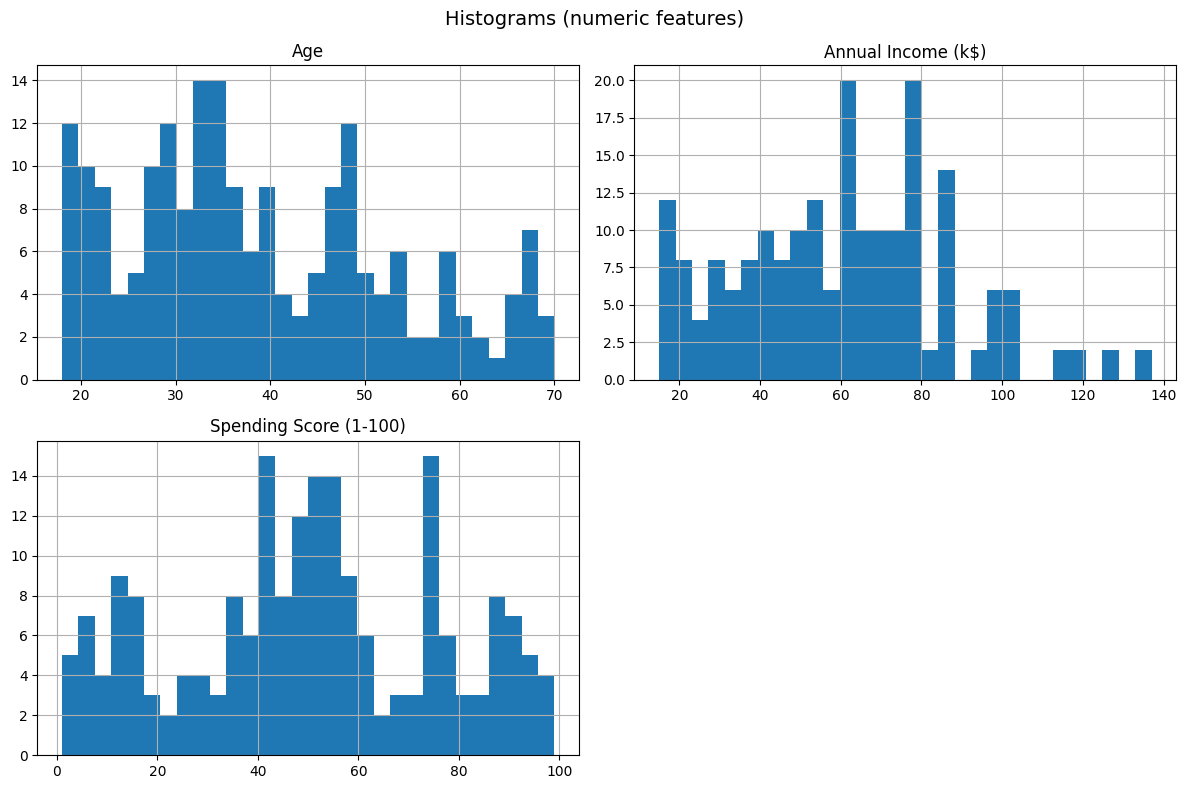

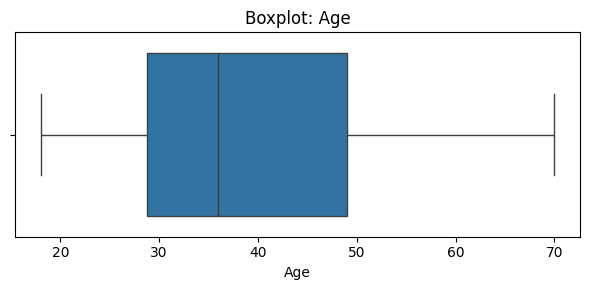

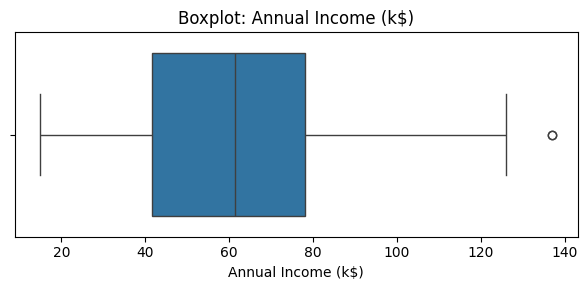

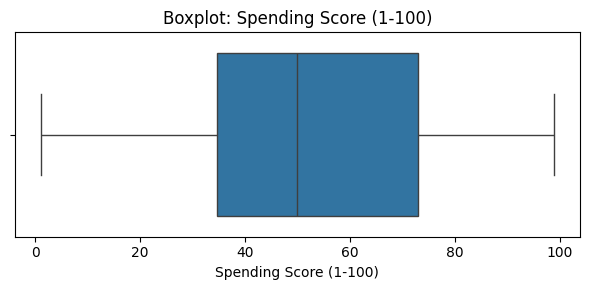

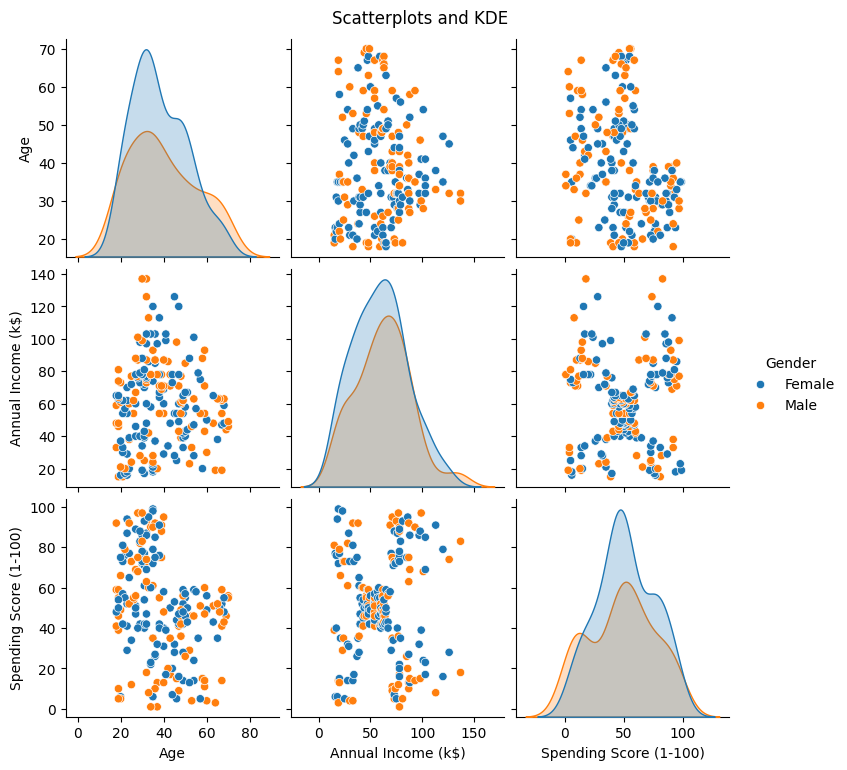

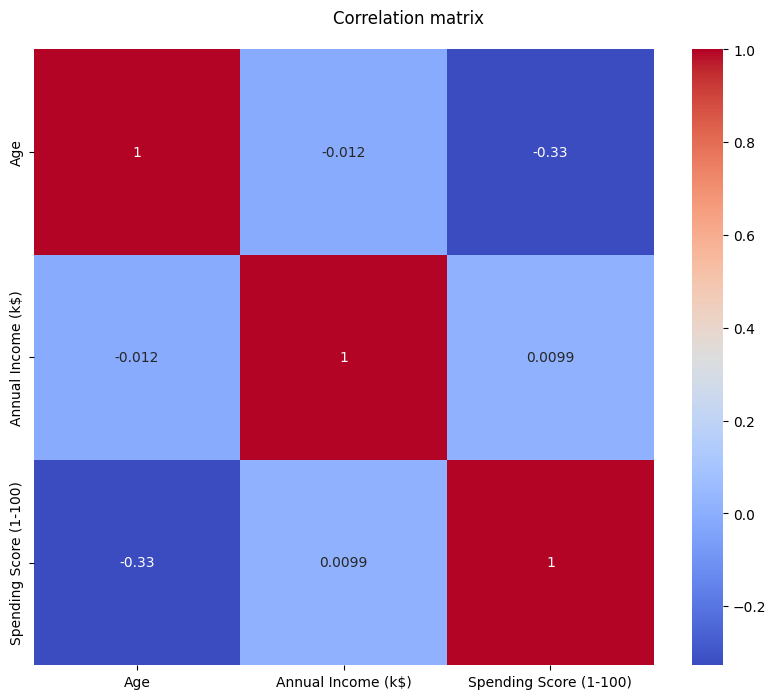

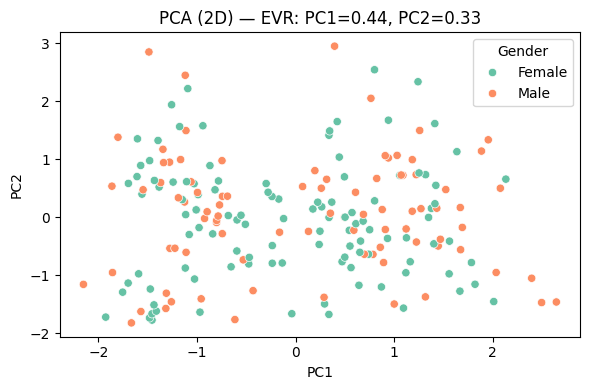

In [6]:
# Visualize data, scatterplots and correlations

num_cols = data.select_dtypes(include=np.number).columns.tolist()
data[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Histograms (numeric features)", fontsize=14)
plt.tight_layout()
plt.show()

# Boxplots
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

# Scatterplot and KDE
sns.pairplot(data, hue="Gender", diag_kind="kde")
plt.suptitle("Scatterplots and KDE", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.suptitle("Correlation matrix", y=0.93)
plt.show()

# PCA 2D projection
    # Choose scaler for scaling
scaler = StandardScaler()
    # Scale the numerical columns
scaled = scaler.fit_transform(data[num_cols].astype(float))
    # Initialize PCA
pca = PCA(n_components=2, random_state=42)
    # Run PCA on the scaled data
pcs = pca.fit_transform(scaled)
    # Create new df with the PCA results
pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["Gender"] = data["Gender"].values
    # Plot PCA & color code based on gender
plt.figure(figsize=(6, 4))
sns.scatterplot(
            data=pca_df,
            x="PC1", y="PC2",
            hue="Gender" if "Gender" else None,
            palette="Set2" if "Gender" else None,
            legend=bool("Gender"),
        )
    # Compute EVR and attach in title
evr = pca.explained_variance_ratio_
plt.title(f"PCA (2D) — EVR: PC1={evr[0]:.2f}, PC2={evr[1]:.2f}")
plt.tight_layout()
plt.show()

# 3. Feature selection, preprocessing and model development
## We use 2 approaches to develop the model.
### The first one is to use the **original** features (scaled) directly from the data set, while the 2nd one involves running a PCA analysis first and using the **components** instead.

In [7]:
# Select only numerical columns from the set
num_cols = data.select_dtypes(include = np.number).columns.tolist()
if len(num_cols) < 2:
    raise ValueError("Need at least 2 numeric columns for PCA / KMeans")

# Define X
X = data[num_cols].copy()

In [8]:
# Scale the data. (Improves convergence times)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

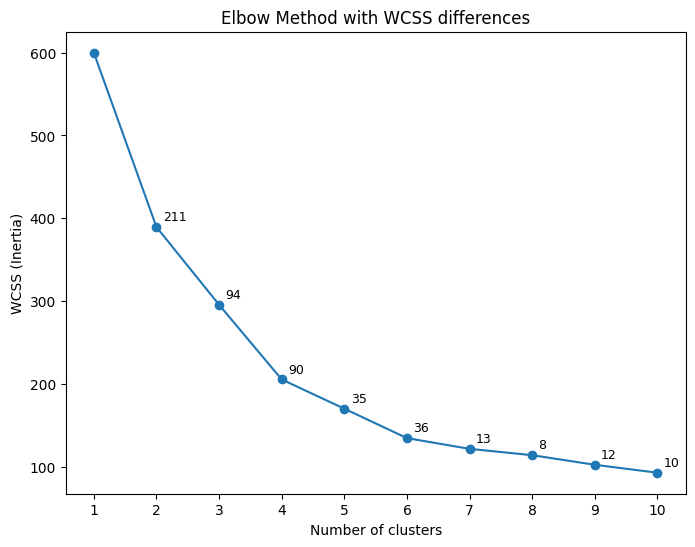

In [9]:
# Run WCSS test (Elbow method)

wcss = []
k_range = range(1,11)
diffs = []

# Fit the data to the model and get WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Compute differences between the WCSS points
diffs = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]

# Plot the WCSS
plt.figure(figsize=(8,6))
plt.plot(k_range, wcss, marker="o")

# Enumerate through diff list and position the number on the graph starting from k=2. i + 0.1 - for x offset, wcss[i-1] + (0.02 * wcss[0]) - for y offset
for i, d in enumerate(diffs, start=2):
    plt.text(
        i + 0.1, wcss[i-1] + (0.02 * wcss[0]), 
        f"{d:.0f}",
        ha="left", va="center", fontsize=9, color="black"
    )

plt.xticks(k_range)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method with WCSS differences")
plt.show()

In [10]:
# Model

kmeans = KMeans(n_clusters = 4, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled)
data["Cluster"] = labels

C:\Users\jdaze\AppData\Local\Temp\ipykernel_18532\3302590418.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


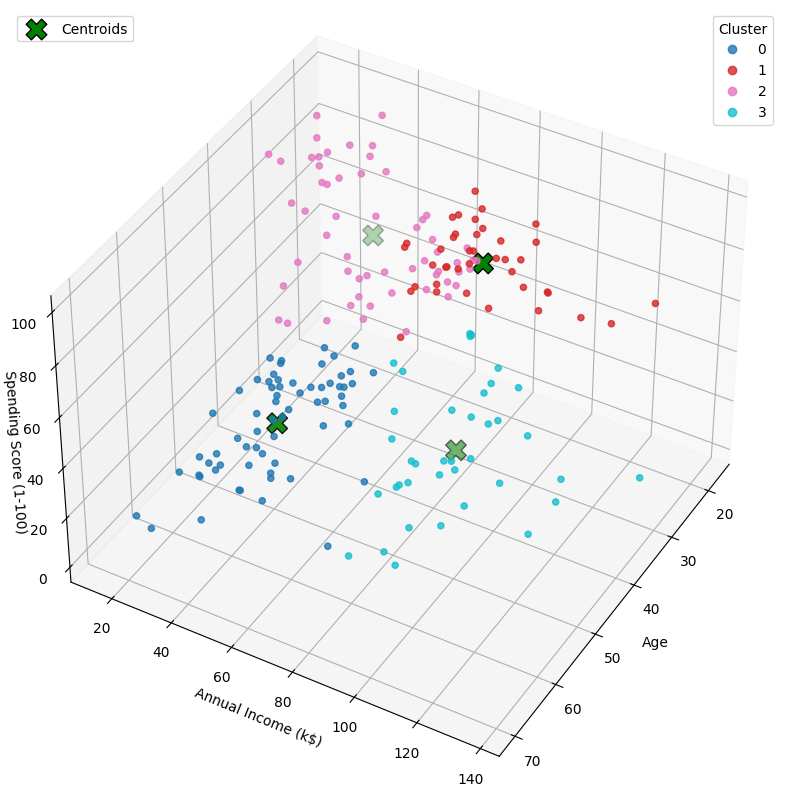

In [11]:
# Plot the clusters

# Since there are 3 features being used, a 3d plot will help visualize the data the best
from mpl_toolkits.mplot3d import Axes3D

# Copy the original data and the centroids coordinates
X_orig = data[num_cols].to_numpy()
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)

# define a 3d plot
fig = plt.figure(figsize=(10,8), constrained_layout = True)
ax = fig.add_subplot(111,projection = "3d")

# add the data points of each column
scatter = ax.scatter(
    X_orig[:,0], X_orig[:,1], X_orig[:,2],
    c = labels, cmap = "tab10", s = 20, alpha = 0.8
)

# add the centroids of the clusters
ax.scatter(
    centers_orig[:,0], centers_orig[:,1], centers_orig[:,2],
    marker = "X", s = 220, edgecolors="black", linewidths=1,
    c = "green", label = "Centroids"
)

# add labels. adjust the text where needed
ax.set_xlabel(num_cols[0]) #Age
ax.set_ylabel(num_cols[1]) #Annual income
ax.set_zlabel(num_cols[2], labelpad=-2, fontsize = 10) #Score

# add legends
legends1 = ax.legend(*scatter.legend_elements(), title = "Cluster", loc = "best")
ax.add_artist(legends1)
ax.legend(loc = "upper left")

# adjust view angle
ax.view_init(elev=40, azim = 30)

plt.tight_layout()
plt.show()

In [12]:
import plotly.graph_objects as go
import plotly.express as px

# Points
fig = px.scatter_3d(
    pd.DataFrame(X_orig, columns=num_cols).assign(cluster=labels),
    x=num_cols[0], y=num_cols[1], z=num_cols[2],
    color="cluster",
    opacity=0.85
)

# Centroids (in original units)
fig.add_trace(go.Scatter3d(
    x=centers_orig[:, 0], y=centers_orig[:, 1], z=centers_orig[:, 2],
    mode='markers',
    marker=dict(size=8, symbol='x', line=dict(width=2, color='black')),
    name='Centroids'
))

fig.update_layout(
    title="KMeans clusters (3D) with centroids",
    scene=dict(
        xaxis_title=num_cols[0],
        yaxis_title=num_cols[1],
        zaxis_title=num_cols[2],
    ),
    legend=dict(itemsizing="constant")
)

fig.show()
fig.write_html("clusters_3d.html", include_plotlyjs="cdn")